# Moving Average filter

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].


Matplotlib is building the font cache; this may take a moment.


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 1/251 — RMSE: 38.12 | MAPE: 1.77% | R²: 0.0442 | Dir Acc: 50.0%
Segment 2/251 — RMSE: 83.83 | MAPE: 3.87% | R²: 0.6157 | Dir Acc: 40.0%
Segment 3/251 — RMSE: 48.09 | MAPE: 2.45% | R²: 0.0002 | Dir Acc: 40.0%
Segment 4/251 — RMSE: 19.75 | MAPE: 1.01% | R²: 0.0062 | Dir Acc: 60.0%
Segment 5/251 — RMSE: 56.40 | MAPE: 2.64% | R²: 0.5097 | Dir Acc: 40.0%
Segment 6/251 — RMSE: 79.85 | MAPE: 3.68% | R²: 0.4211 | Dir Acc: 46.7%
Segment 7/251 — RMSE: 23.94 | MAPE: 1.04% | R²: 0.7541 | Dir Acc: 60.0%
Segment 8/251 — RMSE: 38.35 | MAPE: 1.67% | R²: 0.6755 | Dir Acc: 43.3%
Segment 9/251 — RMSE: 37.54 | MAPE: 1.67% | R²: 0.3481 | Dir Acc: 50.0%
Segment 10/251 — RMSE: 82.74 | MAPE: 3.55% | R²: 0.5698 | Dir Acc: 60.0%
Segment 11/251 — RMSE: 30.30 | MAPE: 1.35% | R²: 0.2041 | Dir Acc: 46.7%
Segment 12/251 — RMSE: 61.23 | MAPE: 2.64% | R²: 0.6599 | Dir Acc: 33.3%
Segment 13/251 — RMSE: 53.84 | MAPE: 2.03% | R²: 0.0714 | Dir Acc: 40.0%
Segment 14/251 — RMSE: 119.41 | MAPE: 4.46% | R²: 0.4934 | D

C:\Users\arabe\AppData\Local\Temp\ipykernel_32772\1979439331.py:162: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


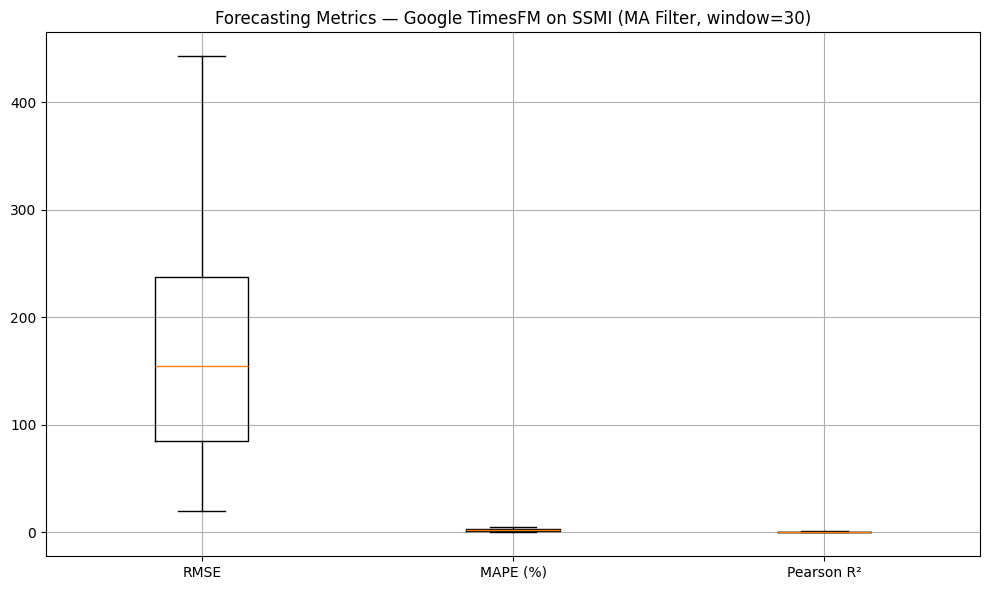

In [1]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='TimesFM_SSMI_Filtered_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def moving_average_filter(y, window=20):
    """Smooth the signal using a moving average (low-frequency trend)."""
    low = np.convolve(y, np.ones(window)/window, mode='same')
    high = y - low  # residual / high-frequency component
    return low, high

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("../DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply filter
        # ========================
        filter_window = 30  # 30-day moving average (approx. 1 trading month)
        y_low, y_high = moving_average_filter(y, window=filter_window)
        logging.info(f"Moving average filter applied with window={filter_window}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120
        forecast_horizon = 30
        step_size        = 30
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load TimesFM
        # ========================
        tfm = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend="cpu",
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
            ),
        )
        logging.info("Google TimesFM loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            # Split context into low and high components
            context_low  = y_low[start_context:end_context].copy()
            context_high = y_high[start_context:end_context].copy()

            # True values (recombined)
            true_low      = y_low[end_context:end_context + forecast_horizon]
            true_high     = y_high[end_context:end_context + forecast_horizon]
            true_combined = true_low + true_high

            # Forecast low-frequency (trend)
            point_forecast_low, _ = tfm.forecast(
                [context_low],
                freq=[0],
            )
            median_low = point_forecast_low[0][:forecast_horizon]

            # Forecast high-frequency (residual)
            point_forecast_high, _ = tfm.forecast(
                [context_high],
                freq=[0],
            )
            median_high = point_forecast_high[0][:forecast_horizon]

            # Recombine predictions
            combined_pred = median_low + median_high

            prev_values = np.concatenate([[y[end_context - 1]], true_combined[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], combined_pred[:-1]])
            actual_direction = np.sign(true_combined - prev_values)
            pred_direction   = np.sign(combined_pred - pred_prev)
            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            # Metrics
            rmse       = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape       = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            pearson_r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R\u00b2={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} \u2014 RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R\u00b2: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("TimesFM_SSMI_Filtered_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            filter_window=filter_window,
                            num_segments=num_segments)
        logging.info("Results saved to TimesFM_SSMI_Filtered_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Google TimesFM on SSMI (MA Filtered) ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R\u00b2: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R\u00b2": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics \u2014 Google TimesFM on SSMI (MA Filter, window={filter_window})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check TimesFM_SSMI_Filtered_Metrics.log for details.")
        try:
            np.savez_compressed("partial_TimesFM_SSMI_Filtered_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

# Hodrick–Prescott filter

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 1/251 — RMSE: 24.08 | MAPE: 1.21% | R²: 0.5391 | Dir Acc: 50.0%
Segment 2/251 — RMSE: 21.47 | MAPE: 1.00% | R²: 0.6234 | Dir Acc: 50.0%
Segment 3/251 — RMSE: 30.82 | MAPE: 0.95% | R²: 0.0008 | Dir Acc: 46.7%
Segment 4/251 — RMSE: 18.85 | MAPE: 0.96% | R²: 0.0106 | Dir Acc: 70.0%
Segment 5/251 — RMSE: 52.11 | MAPE: 2.60% | R²: 0.5269 | Dir Acc: 26.7%
Segment 6/251 — RMSE: 41.00 | MAPE: 2.00% | R²: 0.8561 | Dir Acc: 60.0%
Segment 7/251 — RMSE: 19.48 | MAPE: 0.95% | R²: 0.8220 | Dir Acc: 60.0%
Segment 8/251 — RMSE: 15.12 | MAPE: 0.64% | R²: 0.4619 | Dir Acc: 40.0%
Segment 9/251 — RMSE: 46.94 | MAPE: 1.95% | R²: 0.0701 | Dir Acc: 53.3%
Segment 10/251 — RMSE: 23.17 | MAPE: 1.04% | R²: 0.5560 | Dir Acc: 60.0%
Segment 11/251 — RMSE: 33.32 | MAPE: 1.43% | R²: 0.1569 | Dir Acc: 63.3%
Segment 12/251 — RMSE: 66.19 | MAPE: 2.85% | R²: 0.4663 | Dir Acc: 63.3%
Segment 13/251 — RMSE: 26.86 | MAPE: 1.07% | R²: 0.0190 | Dir Acc: 40.0%
Segment 14/251 — RMSE: 48.09 | MAPE: 1.92% | R²: 0.9172 | Di

C:\Users\arabe\AppData\Local\Temp\ipykernel_32772\3133147820.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


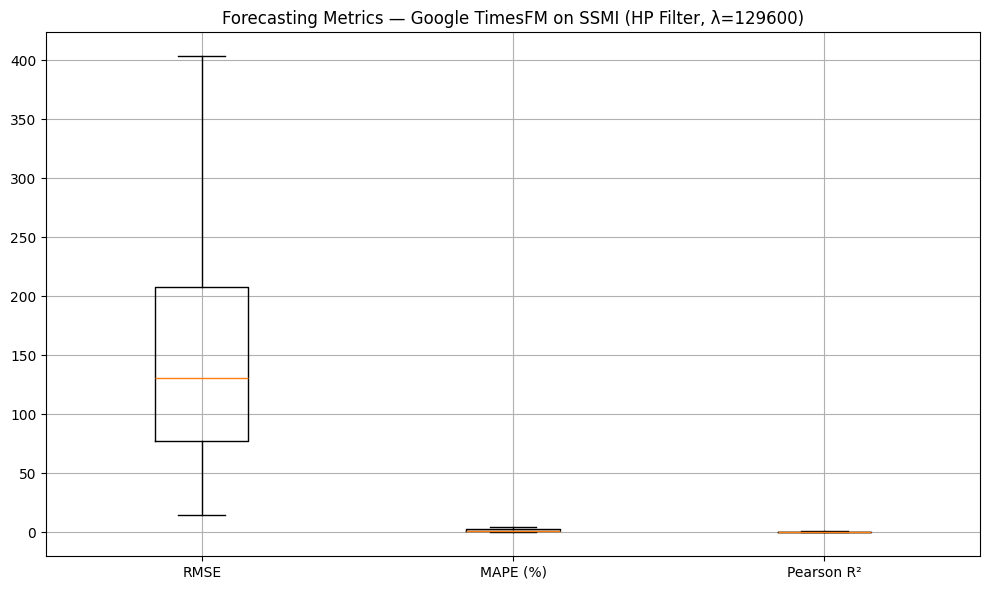

In [2]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.filters.hp_filter import hpfilter
from scipy.stats import pearsonr

logging.basicConfig(
    filename='TimesFM_SSMI_HP_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("../DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply HP filter
        # ========================
        lamb = 129600
        cycle, trend = hpfilter(y, lamb=lamb)
        y_low  = trend
        y_high = cycle
        logging.info(f"HP filter applied with lambda={lamb}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120
        forecast_horizon = 30
        step_size        = 30
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load TimesFM
        # ========================
        tfm = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend="cpu",
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
            ),
        )
        logging.info("Google TimesFM loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            context_low  = y_low[start_context:end_context].copy()
            context_high = y_high[start_context:end_context].copy()

            true_low      = y_low[end_context:end_context + forecast_horizon]
            true_high     = y_high[end_context:end_context + forecast_horizon]
            true_combined = true_low + true_high

            # Forecast low-frequency (trend)
            point_forecast_low, _ = tfm.forecast(
                [context_low],
                freq=[0],
            )
            median_low = point_forecast_low[0][:forecast_horizon]

            # Forecast high-frequency (cycle)
            point_forecast_high, _ = tfm.forecast(
                [context_high],
                freq=[0],
            )
            median_high = point_forecast_high[0][:forecast_horizon]

            # Recombine predictions
            combined_pred = median_low + median_high

            # ========================
            # Directional accuracy
            # (correct up AND correct down)
            # ========================
            prev_day_price = y[end_context - 1]

            # Previous day anchor for actual and forecast
            actual_prev = np.concatenate([[prev_day_price], true_combined[:-1]])
            pred_prev   = np.concatenate([[prev_day_price], combined_pred[:-1]])

            actual_direction = np.sign(true_combined - actual_prev)
            pred_direction   = np.sign(combined_pred  - pred_prev)

            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            # Standard metrics
            rmse = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, R\u00b2={r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} \u2014 RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R\u00b2: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed("TimesFM_SSMI_HP_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            lamb=lamb,
                            num_segments=num_segments)
        logging.info("Results saved to TimesFM_SSMI_HP_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Google TimesFM on SSMI (HP Filter) ---")
        print(f"Median RMSE:          {np.median(rmse_list):.4f}")
        print(f"Median MAPE:          {np.median(mape_list):.4f}%")
        print(f"Median Pearson R\u00b2:    {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":     rmse_list,
            "MAPE (%)":  mape_list,
            "Pearson R\u00b2": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(f"Forecasting Metrics \u2014 Google TimesFM on SSMI (HP Filter, \u03bb={lamb})")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check TimesFM_SSMI_HP_Metrics.log for details.")
        try:
            np.savez_compressed("partial_TimesFM_SSMI_HP_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

# Butterworth lowpass filter

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 1/251 — RMSE: 79.70 | MAPE: 3.82% | R²: 0.1839 | Dir Acc: 43.3%
Segment 2/251 — RMSE: 79.70 | MAPE: 3.67% | R²: 0.5967 | Dir Acc: 40.0%
Segment 3/251 — RMSE: 48.98 | MAPE: 2.52% | R²: 0.0016 | Dir Acc: 33.3%
Segment 4/251 — RMSE: 15.84 | MAPE: 0.82% | R²: 0.1283 | Dir Acc: 70.0%
Segment 5/251 — RMSE: 58.88 | MAPE: 2.80% | R²: 0.3882 | Dir Acc: 43.3%
Segment 6/251 — RMSE: 38.72 | MAPE: 1.87% | R²: 0.9277 | Dir Acc: 66.7%
Segment 7/251 — RMSE: 82.71 | MAPE: 3.50% | R²: 0.8752 | Dir Acc: 26.7%
Segment 8/251 — RMSE: 90.21 | MAPE: 3.82% | R²: 0.6945 | Dir Acc: 40.0%
Segment 9/251 — RMSE: 49.13 | MAPE: 2.07% | R²: 0.3757 | Dir Acc: 53.3%
Segment 10/251 — RMSE: 22.90 | MAPE: 0.95% | R²: 0.6122 | Dir Acc: 53.3%
Segment 11/251 — RMSE: 38.66 | MAPE: 1.98% | R²: 0.1292 | Dir Acc: 53.3%
Segment 12/251 — RMSE: 32.62 | MAPE: 1.44% | R²: 0.6535 | Dir Acc: 60.0%
Segment 13/251 — RMSE: 26.21 | MAPE: 1.18% | R²: 0.3734 | Dir Acc: 50.0%
Segment 14/251 — RMSE: 141.97 | MAPE: 5.34% | R²: 0.7485 | D

C:\Users\arabe\AppData\Local\Temp\ipykernel_32772\2329224733.py:197: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


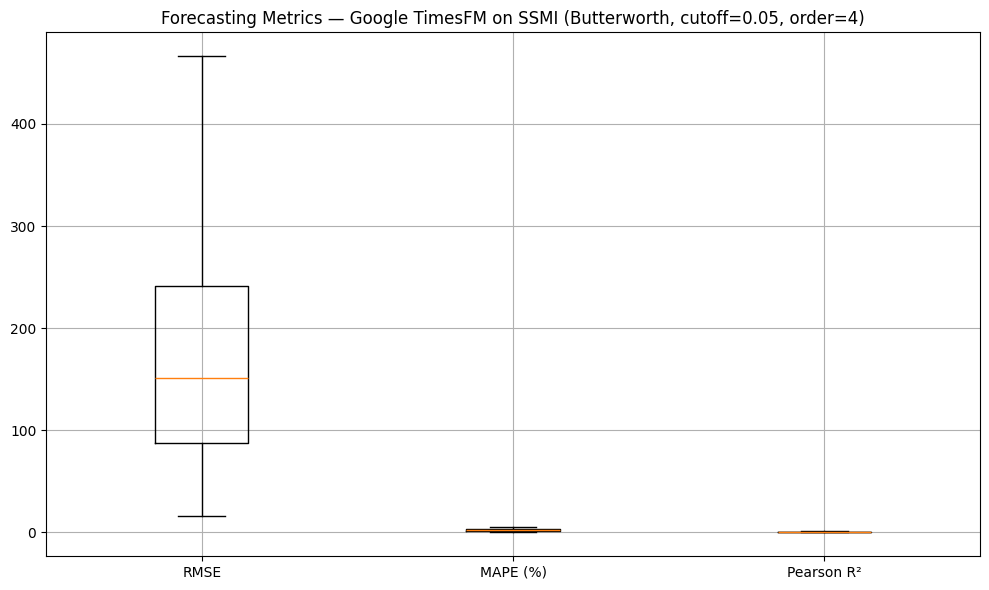

In [3]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr
from scipy.signal import butter, filtfilt

logging.basicConfig(
    filename='TimesFM_SSMI_Butterworth_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def butterworth_filter(y, cutoff=0.05, order=4):
    """
    Low-pass Butterworth filter.

    Parameters
    ----------
    y : array-like
        Input time series.
    cutoff : float
        Normalized cutoff frequency in (0, 1), where 1 corresponds to Nyquist.
    order : int
        Filter order.

    Returns
    -------
    low : np.ndarray
        Low-frequency component.
    high : np.ndarray
        High-frequency residual component.
    """
    b, a = butter(order, cutoff, btype='low')
    low = filtfilt(b, a, y)
    high = y - low
    return low, high

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv(
            "../DataSets/SSMI cleaned/SSMI_cleaned.csv",
            parse_dates=["Date"]
        )
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Apply Butterworth filter
        # ========================
        cutoff = 0.05
        filter_order = 4
        y_low, y_high = butterworth_filter(y, cutoff=cutoff, order=filter_order)
        logging.info(f"Butterworth filter applied with cutoff={cutoff}, order={filter_order}")

        # ========================
        # 3) Sliding window config
        # ========================
        context_window   = 120
        forecast_horizon = 30
        step_size        = 30
        num_segments     = (total_samples - context_window) // step_size
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 4) Load TimesFM
        # ========================
        tfm = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend="cpu",
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
            ),
        )
        logging.info("Google TimesFM loaded successfully.")

        # ========================
        # 5) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window

            if end_context + forecast_horizon > total_samples:
                break

            # Split context into low/high components
            context_low  = y_low[start_context:end_context].copy()
            context_high = y_high[start_context:end_context].copy()

            # True values
            true_combined = y[end_context:end_context + forecast_horizon]

            # Forecast low component
            point_forecast_low, _ = tfm.forecast(
                [context_low],
                freq=[0],
            )
            median_low = point_forecast_low[0][:forecast_horizon]

            # Forecast high component
            point_forecast_high, _ = tfm.forecast(
                [context_high],
                freq=[0],
            )
            median_high = point_forecast_high[0][:forecast_horizon]

            # Recombine predictions
            combined_pred = median_low + median_high

            # Directional accuracy
            prev_values = np.concatenate([[y[end_context - 1]], true_combined[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], combined_pred[:-1]])

            actual_direction = np.sign(true_combined - prev_values)
            pred_direction   = np.sign(combined_pred - pred_prev)

            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            # Metrics
            rmse       = np.sqrt(mean_squared_error(true_combined, combined_pred))
            mape       = mean_absolute_percentage_error(true_combined, combined_pred) * 100
            pearson_r2 = pearsonr(true_combined, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(
                f"Segment {segment+1}/{num_segments}: "
                f"RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R\u00b2={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%"
            )
            print(
                f"Segment {segment+1}/{num_segments} \u2014 "
                f"RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R\u00b2: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%"
            )

        # ========================
        # 6) Save results
        # ========================
        np.savez_compressed(
            "TimesFM_SSMI_Butterworth_Metrics.npz",
            rmse=np.array(rmse_list),
            mape=np.array(mape_list),
            pearson_coefficients=np.array(pearson_list),
            directional_hits=np.array(directional_hits),
            context_window=context_window,
            forecast_horizon=forecast_horizon,
            cutoff=cutoff,
            filter_order=filter_order,
            num_segments=num_segments
        )
        logging.info("Results saved to TimesFM_SSMI_Butterworth_Metrics.npz")

        # ========================
        # 7) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100 if total_days > 0 else 0.0

        print("\n--- Median Metrics for Google TimesFM on SSMI (Butterworth Filter) ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R\u00b2: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 8) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R\u00b2": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title(
            f"Forecasting Metrics \u2014 Google TimesFM on SSMI "
            f"(Butterworth, cutoff={cutoff}, order={filter_order})"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check TimesFM_SSMI_Butterworth_Metrics.log for details.")
        try:
            np.savez_compressed(
                "partial_TimesFM_SSMI_Butterworth_Metrics.npz",
                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None
            )
        except Exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

# Kalman Filter

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 1/251 — RMSE: 71.67 | MAPE: 3.63% | R²: 0.5590 | Dir Acc: 56.7%
Segment 2/251 — RMSE: 38.35 | MAPE: 2.10% | R²: 0.6157 | Dir Acc: 53.3%
Segment 3/251 — RMSE: 50.60 | MAPE: 2.27% | R²: 0.0199 | Dir Acc: 60.0%
Segment 4/251 — RMSE: 22.34 | MAPE: 1.20% | R²: 0.0579 | Dir Acc: 56.7%
Segment 5/251 — RMSE: 64.74 | MAPE: 3.06% | R²: 0.8868 | Dir Acc: 36.7%
Segment 6/251 — RMSE: 36.93 | MAPE: 1.88% | R²: 0.7888 | Dir Acc: 63.3%
Segment 7/251 — RMSE: 88.46 | MAPE: 4.19% | R²: 0.6480 | Dir Acc: 40.0%
Segment 8/251 — RMSE: 41.99 | MAPE: 1.88% | R²: 0.7334 | Dir Acc: 40.0%
Segment 9/251 — RMSE: 41.74 | MAPE: 1.75% | R²: 0.1509 | Dir Acc: 56.7%
Segment 10/251 — RMSE: 78.16 | MAPE: 4.02% | R²: 0.2778 | Dir Acc: 56.7%
Segment 11/251 — RMSE: 63.66 | MAPE: 3.09% | R²: 0.1108 | Dir Acc: 36.7%
Segment 12/251 — RMSE: 78.19 | MAPE: 3.45% | R²: 0.6922 | Dir Acc: 63.3%
Segment 13/251 — RMSE: 32.40 | MAPE: 1.28% | R²: 0.1471 | Dir Acc: 50.0%
Segment 14/251 — RMSE: 155.72 | MAPE: 6.23% | R²: 0.9621 | D

C:\Users\arabe\AppData\Local\Temp\ipykernel_32772\1534008198.py:191: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


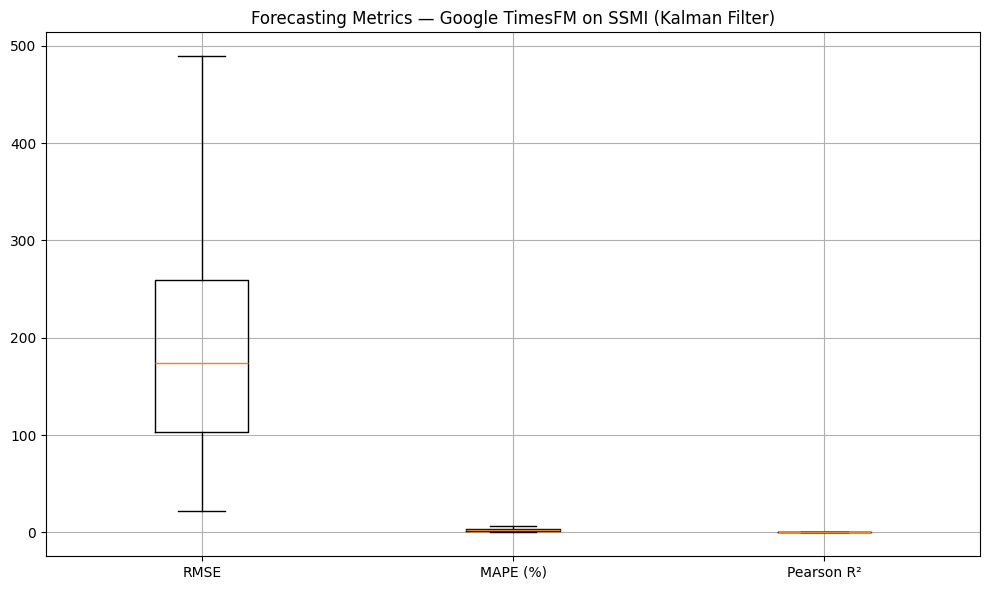

In [4]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.structural import UnobservedComponents
from scipy.stats import pearsonr


logging.basicConfig(
    filename='TimesFM_SSMI_Kalman_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

def kalman_decompose_train_only(y_context, forecast_horizon):
    """
    Fit a local linear trend state-space model on context only.
    Use filtered states (not smoothed) to avoid look-ahead leakage.
    Forecast the low-frequency trend forward, and model the high-frequency
    component as the filtered residual with zero-mean future expectation.
    """
    model = UnobservedComponents(
        y_context,
        level='local linear trend'
    )
    result = model.fit(disp=False)

    # Use filtered state estimates only: past information up to each time t
    filtered_level = result.level.filtered
    low_context = np.asarray(filtered_level, dtype=float)
    high_context = np.asarray(y_context - low_context, dtype=float)

    # Forecast only the low-frequency component
    low_forecast = np.asarray(result.forecast(steps=forecast_horizon), dtype=float)

    # Zero-mean assumption for future residual/high-frequency component
    high_forecast = np.zeros(forecast_horizon, dtype=float)

    return low_context, high_context, low_forecast, high_forecast, result

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv(
            "../DataSets/SSMI cleaned/SSMI_cleaned.csv",
            parse_dates=["Date"]
        )
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Sliding window config
        # ========================
        context_window = 120
        forecast_horizon = 30
        step_size = 30
        num_segments = (total_samples - context_window - forecast_horizon) // step_size + 1
        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 3) Load TimesFM
        # ========================
        tfm = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend="cpu",
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
            ),
        )
        logging.info("Google TimesFM loaded successfully.")

        # ========================
        # 4) Rolling evaluation
        # ========================
        rmse_list = []
        mape_list = []
        pearson_list = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context = start_context + context_window
            forecast_end = end_context + forecast_horizon

            if forecast_end > total_samples:
                break

            y_context = y[start_context:end_context]
            y_true = y[end_context:forecast_end]

            # Kalman decomposition fitted only on context
            low_context, high_context, low_forecast_kf, high_forecast_kf, _ = kalman_decompose_train_only(
                y_context,
                forecast_horizon
            )

            # TimesFM forecasts the two components separately
            point_forecast_low, _ = tfm.forecast(
                [low_context.copy()],
                freq=[0],
            )
            point_forecast_high, _ = tfm.forecast(
                [high_context.copy()],
                freq=[0],
            )

            # Combine forecasts
            median_low  = point_forecast_low[0][:forecast_horizon]
            median_high = point_forecast_high[0][:forecast_horizon]
            combined_pred = median_low + median_high

            prev_day_price = y[end_context - 1]
            actual_prev = np.concatenate([[prev_day_price], y_true[:-1]])
            pred_prev = np.concatenate([[prev_day_price], combined_pred[:-1]])

            actual_direction = np.sign(y_true - actual_prev)
            pred_direction = np.sign(combined_pred - pred_prev)
            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            rmse = np.sqrt(mean_squared_error(y_true, combined_pred))
            mape = mean_absolute_percentage_error(y_true, combined_pred) * 100
            r2 = pearsonr(y_true, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(
                f"Segment {segment+1}/{num_segments}: "
                f"RMSE={rmse:.4f}, MAPE={mape:.4f}%, "
                f"R2={r2:.4f}, DirAcc={segment_dir_acc:.1f}%"
            )
            print(
                f"Segment {segment+1}/{num_segments} \u2014 "
                f"RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | "
                f"R\u00b2: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%"
            )

        # ========================
        # 5) Save results
        # ========================
        np.savez_compressed(
            "TimesFM_SSMI_Kalman_Metrics.npz",
            rmse=np.array(rmse_list),
            mape=np.array(mape_list),
            pearson_coefficients=np.array(pearson_list),
            directional_hits=np.array(directional_hits),
            context_window=context_window,
            forecast_horizon=forecast_horizon,
            step_size=step_size,
            num_segments=len(rmse_list)
        )
        logging.info("Results saved to TimesFM_SSMI_Kalman_Metrics.npz")

        # ========================
        # 6) Summary metrics
        # ========================
        total_days = len(directional_hits)
        total_hits = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100 if total_days > 0 else np.nan

        print("\n--- Median Metrics for Google TimesFM on SSMI (Kalman Filter) ---")
        print(f"Median RMSE:          {np.median(rmse_list):.4f}")
        print(f"Median MAPE:          {np.median(mape_list):.4f}%")
        print(f"Median Pearson R\u00b2:    {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 7) Box plots
        # ========================
        metrics = {
            "RMSE": rmse_list,
            "MAPE (%)": mape_list,
            "Pearson R\u00b2": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title("Forecasting Metrics \u2014 Google TimesFM on SSMI (Kalman Filter)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check TimesFM_SSMI_Kalman_Metrics.log for details.")
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()